In [1]:
import os
import seaborn as sns
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import numpy as np

%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

In [7]:
from hbn.scripts import preprocess_phenotype
from hbn.data import make_dataset

# preprocess phenotype data and return clinical summary
dx = preprocess_phenotype.run()

# add race and ethnicity data to the clinical summary
dx = make_dataset._add_race_ethnicity(dataframe=dx)

# filter for adhd + no diagnosis
adhd_only = ['ADHD-Combined Type', 'ADHD-Hyperactive/Impulsive Type', 'ADHD-Inattentive Type', 'No Diagnosis Given']
dx = dx[dx['DX_01'].isin(adhd_only)]

phenotypic data have already been parsed...
phenotypic data have already been parsed...
phenotypic data have already been parsed...
phenotypic data have already been parsed...
created new clinical diagnosis file
writing train and test participants to file for ADHD
writing train and test participants to file for Anxiety_Disorders
writing train and test participants to file for Autism_Spectrum_Disorder
writing train and test participants to file for Bipolar_and_Related_Disorders
writing train and test participants to file for Depressive_Disorders
writing train and test participants to file for Disruptive__Impulse_Control_and_Conduct_Disorders
writing train and test participants to file for Elimination_Disorders
writing train and test participants to file for Feeding_and_Eating_Disorders
could not write out train and test participants for Gender_Dysphoria -- likely too few samples
could not write out train and test participants for Neurocognitive_Disorders -- likely too few samples
writin

In [103]:
## FUNCTIONS

## GET DATA from parent intake interview

def get_data(preprocess=False, target_col='DX_01_Cat'):

    import pandas as pd
    from hbn.features import build_features
    from hbn.data import make_dataset

    # get features
    features = build_features.get_features(
                assessment='Parent Measures',
                domains=['Demographic Questionnaire Measures'],
                measures=['Barratt Simplified Measure of Social_Status'],
                min_num_participants=2000,
                incl_data_type=None
                );

    if preprocess:
        # preprocess features 
        clf_info={"numeric": [[
                        "sklearn.impute",
                        "SimpleImputer",
                        {"strategy": "mean"}]
                ]
                }
        features = build_features.preprocess(
                                            dataframe=features,
                                            clf_info=clf_info,
                                            cols_to_ignore=['Identifiers']
                                            )

    # get targets
    targets = build_features.get_targets(target_info = {
                                        "assessment": "Clinical Measures",
                                        "domain": None,
                                        "measure": "Clinical Diagnosis Demographics",
                                        "target_column": target_col,
                                        "transform": None,
                                        "outname":target_col
                                        })
    # get participant ids
    participants = make_dataset.get_participants(
                                split='all', 
                                disorders=['ADHD-Combined Type', 
                                            'ADHD-Inattentive Type', 
                                            'ADHD-Hyperactive_Impulsive_Type', 
                                            'No_Diagnosis_Given']
                                )

    features_target = features.merge(
                                targets, on='Identifiers').merge(
                                participants, on='Identifiers')
    # get feature names
    feature_names = [col for col in features_target.columns if target_col not in col]
    
    df_concat = pd.concat([features_target[[target_col]], features_target[feature_names]], axis=1)

    return df_concat


def code_professions(x):
    data_dict = {0: ["No employment or data not collected"],
                5: ["Day laborer", "janitor", "house cleaner", "farm worker", "food counter sales", "food preparation worker", "busboy"],
                10: ["Garbage collector", "short-order cook", "cab driver", "shoe sales", "assembly line workers", "masons", "baggage porter"],
                15: ["Automobile mechanic", "typist", "locksmith", "farmer", "carpenter", "receptionist", "construction laborer", "hairdresser"],
                20: ["Automobile mechanic", "typist", "locksmith", "farmer", "carpenter", "receptionist", "construction laborer", "hairdresser"],
                25: ["Machinist", "musician", "bookkeeper", "secretary", "insurance sales", "cabinet maker", "personnel specialist", "welder"],
                30: ["Supervisor", "librarian", "aircraft mechanic", "artist and artisan", "electrician", "administrator", "military enlisted personnel", "buyer"],
                35: ["Nurse", "skilled technician", "medical technician", "counselor", "manager", "police and fire personnel", "financial manager", "physical therapist", "occupational therapist", "speech therapist"],
                40: ["Mechanical engineer", "nuclear engineer", "electrical engineer", "educational administrator", "veterinarian", "military officer", "elementary teacher", "high school and special education teacher"],
                45: ["Physician", "attorney", "professor", "chemical and aerospace engineer", "judge", "CEO", "senior manager", "public official", "psychologist", "pharmacist", "accountant"]
                }
    if x!='not collected':
        return data_dict[x]

def code_education(x):
    data_dict = {3: 'Less than 7th grade',
                6: 'Junior high/Middle school (9th grade)',
                9: 'Partial high school (10th or 11th grade)',
                12: 'High school graduate',
                15: 'Partial college (at least one year)',
                18: 'College education',
                21: 'Graduate degree'
                }
    if x!='not collected':
        return data_dict[x]

    

In [104]:
## RUN THIS CELL ## 
from hbn.constants import Defaults
from hbn.data import make_dataset

# get data from intake interview and merge with clinical summary
df = get_data()
df = df.merge(dx[['Sex', 'Age_bracket', 'PreInt_Demos_Fam,Child_Race_cat','Identifiers']], on='Identifiers')



reading /Users/maedbhking/Documents/healthy_brain_network/data/raw/phenotype/Parent_Measures/Demographic_Questionnaire_Measures/Barratt_Simplified_Measure_of_Social_Status.csv into dataframe
reading /Users/maedbhking/Documents/healthy_brain_network/data/raw/phenotype/Clinical_Measures/Clinical_Diagnosis_Demographics.csv into dataframe


## No notable differences between ADHD subtypes + no diagnosis for total level of education

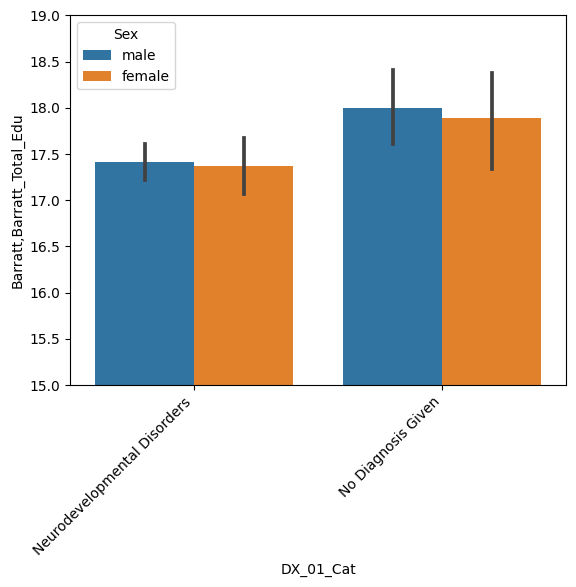

In [106]:
colors = ['Sex']
var = 'Barratt,Barratt_Total_Edu'

for color in colors:
    #fig = px.bar(df, x="DX_01", y=var, color=color,orientation='v', barmode="group")
    sns.barplot(df, x='DX_01_Cat', y=var, hue=color)
    plt.ylim((15,19))
    plt.xticks(rotation = 45, ha="right")
    plt.show()

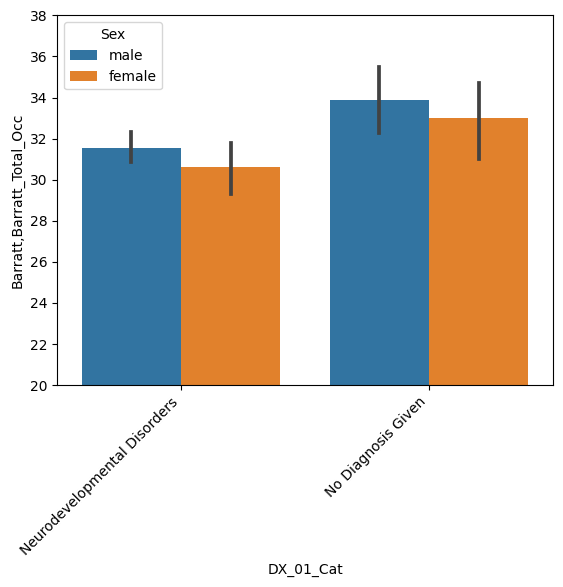

In [108]:
colors = ['Sex']
var = 'Barratt,Barratt_Total_Occ'

for color in colors:
    #fig = px.bar(df, x="DX_01", y=var, color=color,orientation='v', barmode="group")
    sns.barplot(df, x='DX_01_Cat', y=var, hue=color)
    plt.ylim((20,38))
    plt.xticks(rotation = 45, ha="right")
    plt.show()

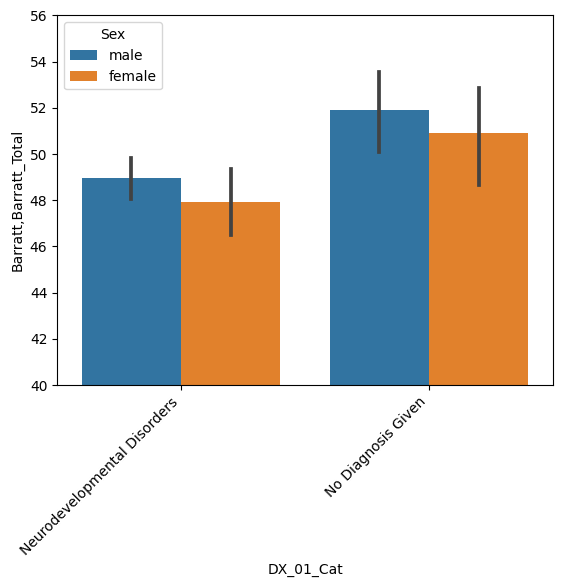

In [110]:
colors = ['Sex']
var = 'Barratt,Barratt_Total'

for color in colors:
    #fig = px.bar(df, x="DX_01", y=var, color=color,orientation='v', barmode="group")
    sns.barplot(df, x='DX_01_Cat', y=var, hue=color)
    plt.ylim((40,56))
    plt.xticks(rotation = 45, ha="right")
    plt.show()

In [99]:
# get education and occupation for each parent
df_new = df.fillna('not collected')
df_new['Barratt,Barratt_P1_Edu_code'] = df_new['Barratt,Barratt_P1_Edu'].apply(lambda x: code_education(x))
df_new['Barratt,Barratt_P2_Edu_code'] = df_new['Barratt,Barratt_P2_Edu'].apply(lambda x: code_education(x))

df_new['Barratt,Barratt_P1_Occ_code'] = df_new['Barratt,Barratt_P1_Occ'].apply(lambda x: code_professions(x))
df_new['Barratt,Barratt_P2_Occ_code'] = df_new['Barratt,Barratt_P2_Occ'].apply(lambda x: code_professions(x))
